In [1]:
import numpy as np
import pandas as pd
import h5py
from astropy.io import fits
import warnings
from tqdm import tqdm
from matplotlib import pyplot as plt

In [2]:
def read_quasars_from_hdf5(file_path):
    quasar_list = []
    with h5py.File(file_path, "r") as hdf:
        for group_name in hdf.keys():
            group = hdf[group_name]
            quasar = {"object_id": group_name}
            for key, value in group.attrs.items():
                quasar[key] = value
            for sub_group_name in group.keys():
                sub_group = group[sub_group_name]
                quasar[sub_group_name] = {sub_key: sub_group[sub_key][...] for sub_key in sub_group.keys()}
            quasar_list.append(quasar)
    return quasar_list


filters = {"u": 0, "g": 1, "r": 2, "i": 3, "z": 4, "y": 5} # harcoded filter order for SDSS


def populate_sdss_fields(objs, progress_bar=False):
    print(f"Populating SDSS fields: {len(objs)}", flush=True)
    cat = pd.read_parquet(f"data/S82/Catalog.parquet").set_index('idx')
    hdul = fits.open('data/dr16q_prop_May01_2024.fits')
    fits_data = hdul[1].data  # Assuming the data is in the first extension    
    fits_data_2 = hdul[2].data  # Assuming the data is in the first extension    
    for d in tqdm(objs, desc="Populating SDSS fields", disable=(not progress_bar)):
        obj = cat.loc[cat['objectId'] == d['object_id']].iloc[0]
        i = np.argwhere(d['sdss_name'] == fits_data['SDSS_NAME']).flatten()
        if len(i) == 0:
            print(f"Warning: {d['sdss_name']} not found in SDSS data")
            return d

        i = i[0]
        # if np.any(fits_data_2['PSFFLUX'][i,:] <= 0):
        #     #print(f"Warning: {d['sdss_name']} has non-positive PSFFLUX values")
        #     continue
        
        d['z'] = obj['Z_SYS']
        d['M_i'] = fits_data_2['M_I'][i]
        d['sdss_name'] = fits_data['SDSS_NAME'][i]  # Extract SDSS_NAME
        d['ebv'] = fits_data['EBV'][i]
        d['EXTINCTION'] = np.mean(fits_data_2['EXTINCTION'][i])
        d['FHOST_5100'] = fits_data['FHOST_5100'][i]
        d['SN_MEDIAN_ALL'] = fits_data['SN_MEDIAN_ALL'][i]
    return objs

objs = read_quasars_from_hdf5("data/may8_lc_all.h5")
#objs = read_quasars_from_hdf5("data/july8_sdss_objs_rest_length_rf_exactly2000.h5")
print(len(objs))


sdss_objs = populate_sdss_fields(objs, progress_bar=True)
#sdss_objs = [obj for obj in sdss_objs if obj.get('M_i', np.inf) < 0]
print(len(objs))
print(len(sdss_objs))

38825
Populating SDSS fields: 38825


Populating SDSS fields: 100%|██████████| 38825/38825 [02:25<00:00, 266.67it/s]

38825
38825


In [3]:
sdss_objs[0].keys()

dict_keys(['object_id', 'dec', 'log_lbol', 'log_lbol_err', 'log_ledd_ratio', 'log_ledd_ratio_err', 'log_mbh', 'log_mbh_err', 'mags_mean', 'ra', 'sdss_name', 'z', 'magerrs', 'mags', 'times', 'M_i', 'ebv', 'EXTINCTION', 'FHOST_5100', 'SN_MEDIAN_ALL'])

In [4]:
selected_objs = [obj for obj in sdss_objs if ((obj['ebv'] < 0.05) and (obj['SN_MEDIAN_ALL'] > 3))]
print(f"Number of selected objects with ebv < 0.05: {len(selected_objs)}")

Number of selected objects with ebv < 0.05: 14131


In [6]:
import numpy as np
from scipy.stats import median_abs_deviation as mad
from multiprocessing import cpu_count, Pool
from tqdm import tqdm
import pandas as pd

def reject_outliers_moving_window(times, mags, mag_errs, window_size=6, sigma_thresh=2.5):
    mags = np.array(mags)
    times = np.array(times)
    mag_errs = np.array(mag_errs)

    if len(mags) < 2 * window_size + 1:
        return mags, mag_errs

    mask = np.ones(len(mags), dtype=bool)

    for i in range(len(mags)):
        if i < window_size or i >= len(mags) - window_size:
            continue
        window = mags[i - window_size:i + window_size + 1]
        window_mad = mad(window, nan_policy='omit')
        window_mean = np.nanmean(window)

        if window_mad == 0:
            continue

        if np.abs(mags[i] - window_mean) > sigma_thresh * window_mad:
            mask[i] = False

    return mags[mask], mag_errs[mask]

def chi_squared_variability(mags, mag_errs):
    mags = np.array(mags)
    mag_errs = np.array(mag_errs)

    if len(mags) <= 1:
        return np.nan

    weights = 1.0 / mag_errs**2
    weighted_mean = np.sum(weights * mags) / np.sum(weights)

    chi_sq = np.sum(((mags - weighted_mean) / mag_errs) ** 2)
    chi_sq_red = chi_sq / (len(mags) - 1)
    return chi_sq_red

def rank_agn_by_chi_squared(object_id, lc_data, window_size=6, sigma_thresh=2.5, band='g'):
    """
    Rank AGN light curves using reduced chi-squared after outlier rejection.
    """
    times, mags, mag_errs = lc_data['times'][band], lc_data['mags'][band], lc_data['magerrs'][band]
    mags_clean, mag_errs_clean = reject_outliers_moving_window(
        times, mags, mag_errs, window_size, sigma_thresh)

    if len(mags_clean) < 2:
        return object_id, np.nan

    chi_sq = chi_squared_variability(mags_clean, mag_errs_clean)
    return object_id, chi_sq

def rank_multiband_light_curves_chi_squared(light_curves):
    results = []
    for lc_data in tqdm(light_curves, desc="Ranking light curves (chi-squared)"):
        r = rank_agn_by_chi_squared(lc_data['object_id'], lc_data)
        try:
            object_id, chi_sq = r
            result_dict = dict(object_id=object_id, chi_sq=chi_sq)
            result_dict.update(lc_data)
            results.append(result_dict)
        except Exception as e:
            print(f"Error processing light curve for object_id {lc_data['object_id']}: {r}")
            print(e)
            continue
    return results
    # ranking_df = pd.DataFrame(results)
    # ranking_df.sort_values('chi_sq', ascending=False, inplace=True)
    # return ranking_df.reset_index(drop=True)

results = rank_multiband_light_curves_chi_squared(selected_objs)
df = pd.DataFrame(results)

Ranking light curves (chi-squared): 100%|██████████| 14131/14131 [01:31<00:00, 154.27it/s]


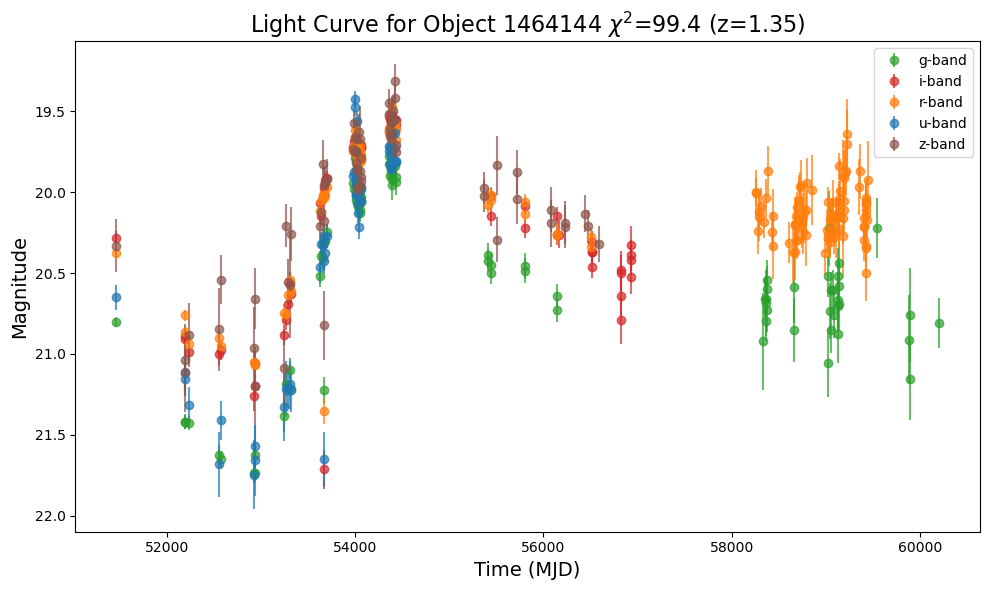

In [7]:
colors = {'u': 'tab:blue',
          'g': 'tab:green', 
          'r': 'tab:orange', 
          'i': 'tab:red', 
          'z': 'tab:brown', 
          'y': 'tab:gray'}

def save_lc_plot(times, mags, magerrs, chi_sq, z, object_id):
    # Plot and save the light curves
    fig, ax = plt.subplots(figsize=(10, 6))
    for band in mags.keys():
        if len(times[band]) > 0:
            ax.errorbar(times[band], mags[band], yerr=magerrs[band], fmt='o', label=f'{band}-band', alpha=0.7, color=colors[band])

    ax.set_xlabel('Time (MJD)', fontsize=14)
    ax.set_ylabel('Magnitude', fontsize=14)
    ax.invert_yaxis()  # Magnitudes are brighter when lower
    ax.legend()
    ax.set_title(fr'Light Curve for Object {object_id} $\chi^2$={chi_sq:.1f} (z={z:.2f})', fontsize=16)
    plt.tight_layout()

    plt.show()
    #plt.close(fig)

# Find an object_id from df with chi_sq == 0
row = df.iloc[(df['chi_sq'] - 100).abs().argmin()]
object_id = row['object_id']

# Find the corresponding object in selected_objs
d = next(obj for obj in selected_objs if obj['object_id'] == object_id)

save_lc_plot(times=d['times'], mags=d['mags'], magerrs=d['magerrs'], z=row['z'], chi_sq=row['chi_sq'], object_id=d['object_id'])

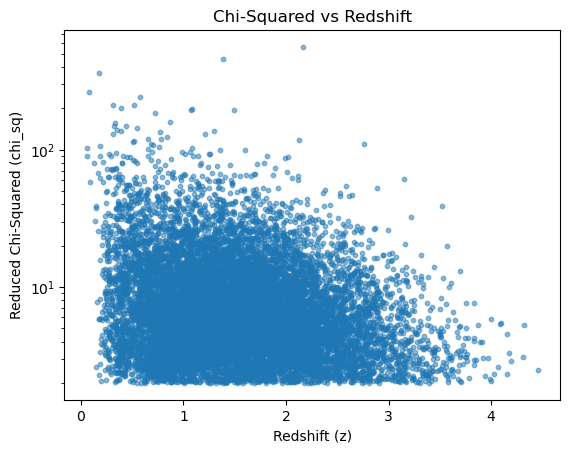

In [95]:
mask = df['chi_sq'] > 2
plt.scatter(df['z'][mask], df['chi_sq'][mask], alpha=0.5, s=10)
plt.xlabel('Redshift (z)')
plt.ylabel('Reduced Chi-Squared (chi_sq)')
plt.title('Chi-Squared vs Redshift')
plt.yscale('log')
plt.show()

In [8]:
good_sources = df[
    (df['chi_sq'] > 2) & 
    (df['ebv'] < 0.05) & 
    (df['SN_MEDIAN_ALL'] > 3)   # reliable spectrum
]
good_sources = good_sources.reset_index(drop=True)
good_sources = good_sources.sample(frac=1, random_state=42).reset_index(drop=True)
good_sources.to_csv('data/aug1_chisq2_ebv_sn_allfields.csv', index=False)
len(good_sources)

12908

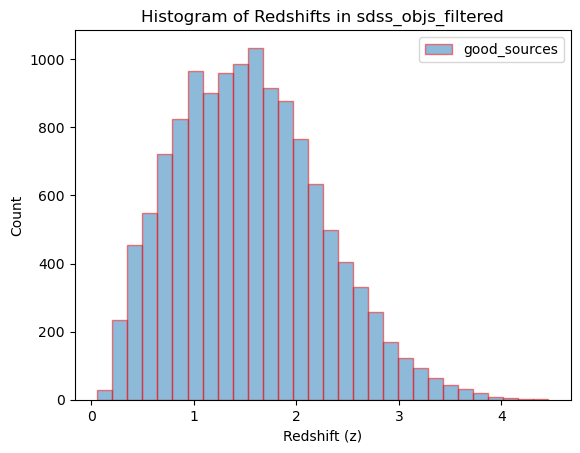

In [93]:
import matplotlib.pyplot as plt

plt.hist(good_sources['z'], bins=30, edgecolor='red', alpha=0.5, label='good_sources')
plt.legend()
plt.xlabel('Redshift (z)')
plt.ylabel('Count')
plt.title('Histogram of Redshifts in sdss_objs_filtered')
plt.show()

In [1]:
plt.hist(good_sources['M_i'], bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Absolute i-band Magnitude (M_i)')
plt.ylabel('Count')
plt.title('Histogram of M_i for good_sources')
plt.show()

NameError: name 'plt' is not defined

In [106]:
df.to_csv("data/may22_agn_all_ranked_chi2.csv", index=False)

In [107]:
df_sel = df[:4000]
df_sel = df_sel.sample(frac=1, random_state=42).reset_index(drop=True)
df_sel.to_csv("data/may22_agn_all_ranked_chi2_4000.csv", index=False)

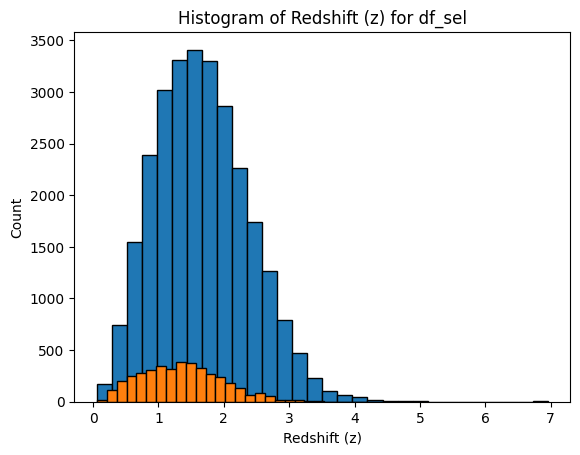

In [108]:
import matplotlib.pyplot as plt

plt.hist(df['z'], bins=30, edgecolor='black')
plt.hist(df_sel['z'], bins=30, edgecolor='black')
plt.xlabel('Redshift (z)')
plt.ylabel('Count')
plt.title('Histogram of Redshift (z) for df_sel')
plt.show()

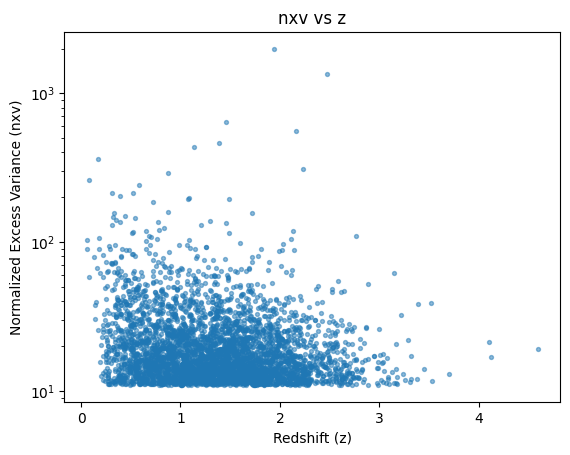

In [111]:
plt.scatter(df_sel['z'], df_sel['chi_sq'], alpha=0.5, s=8)
plt.xlabel('Redshift (z)')
plt.ylabel('Normalized Excess Variance (nxv)')
plt.title('nxv vs z')
plt.yscale('log')
plt.show()

In [87]:
df = df[df['ebv'] < 0.05]
len(df)

27769

In [64]:
d = df[df['total_observations'] > 800]
d

,object_id,robust_avg_nxv,total_observations,combined_score
28,1459958,0.001931,986,0.005780
66,1463119,0.000966,963,0.002882
78,1427359,0.000903,811,0.002627
88,1424290,0.000785,973,0.002344
108,1465974,0.000661,1060,0.001999
...,...,...,...,...
35723,1451585,0.000003,1612,0.000010
36016,1401309,0.000003,805,0.000009
36391,1385141,0.000002,1089,0.000006
36473,1464956,0.000002,1317,0.000005


In [65]:
d.to_csv('data/s82_lc_ranking.csv', index=False)